In [3]:
import pandas as pd
from data_builder import DataBuilder
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    standardized_array = (input_array - mean) / std
    return standardized_array

In [3]:
beam_break_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/master_binary.csv')
beam_break_data

/tmp/ipykernel_1311400/1559551854.py:1: DtypeWarning: Columns (1,2,20079) have mixed types. Specify dtype option on import or set low_memory=False.
  beam_break_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/master_binary.csv')


,FlyID,Genotype_SpecSheet,Genotype (F>M),RunName,Monitor,Channel,StartMeta,EndMeta,TimeLen,t0,...,t20062,t20063,t20064,t20065,t20066,t20067,Average bout length/D,Activity/waking min,Genotype (FxM)_specsheet,Genotype (FxM)
0,M106_M118_Ch25,Londonxalrm_1_M,London>alrm,M106,118,25,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,88.206897,2.891771,NaN,NaN
1,M106_M118_Ch26,Londonxalrm_1_M,London>alrm,M106,118,26,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.576923,1.933168,NaN,NaN
2,M106_M118_Ch27,Londonxalrm_1_M,London>alrm,M106,118,27,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,62.487179,2.523714,NaN,NaN
3,M106_M118_Ch28,Londonxalrm_1_M,London>alrm,M106,118,28,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,216.083333,1.665618,NaN,NaN
4,M106_M118_Ch29,Londonxalrm_1_M,London>alrm,M106,118,29,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39.933333,2.639334,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,M96_M48_Ch28,elav>attp2vF,NaN,M96,48,28,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,1.0,3.0,2.0,1.0,1.0,86.413793,2.272366,NaN,NaN
1359,M96_M48_Ch29,elav>attp2vF,NaN,M96,48,29,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,2.0,1.0,1.0,2.0,2.0,28.743243,2.505122,NaN,NaN
1360,M96_M48_Ch30,elav>attp2vF,NaN,M96,48,30,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,26.519481,2.455212,NaN,NaN
1361,M96_M48_Ch31,elav>attp2vF,NaN,M96,48,31,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,3.0,0.0,1.0,1.0,0.0,1.0,48.088889,2.453503,NaN,NaN


In [4]:
beam_break_data['Genotype_SpecSheet'].isna().sum()

157

In [5]:
beam_break_data = beam_break_data.dropna(subset='Genotype_SpecSheet').reset_index(drop=True)
beam_break_data

,FlyID,Genotype_SpecSheet,Genotype (F>M),RunName,Monitor,Channel,StartMeta,EndMeta,TimeLen,t0,...,t20062,t20063,t20064,t20065,t20066,t20067,Average bout length/D,Activity/waking min,Genotype (FxM)_specsheet,Genotype (FxM)
0,M106_M118_Ch25,Londonxalrm_1_M,London>alrm,M106,118,25,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,88.206897,2.891771,NaN,NaN
1,M106_M118_Ch26,Londonxalrm_1_M,London>alrm,M106,118,26,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.576923,1.933168,NaN,NaN
2,M106_M118_Ch27,Londonxalrm_1_M,London>alrm,M106,118,27,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,62.487179,2.523714,NaN,NaN
3,M106_M118_Ch28,Londonxalrm_1_M,London>alrm,M106,118,28,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,216.083333,1.665618,NaN,NaN
4,M106_M118_Ch29,Londonxalrm_1_M,London>alrm,M106,118,29,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39.933333,2.639334,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,NaN,M96,48,28,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,1.0,3.0,2.0,1.0,1.0,86.413793,2.272366,NaN,NaN
1202,M96_M48_Ch29,elav>attp2vF,NaN,M96,48,29,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,2.0,1.0,1.0,2.0,2.0,28.743243,2.505122,NaN,NaN
1203,M96_M48_Ch30,elav>attp2vF,NaN,M96,48,30,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,26.519481,2.455212,NaN,NaN
1204,M96_M48_Ch31,elav>attp2vF,NaN,M96,48,31,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,3.0,0.0,1.0,1.0,0.0,1.0,48.088889,2.453503,NaN,NaN


In [6]:
beam_break_data.columns

Index(['FlyID', 'Genotype_SpecSheet', 'Genotype (F>M)', 'RunName', 'Monitor',
       'Channel', 'StartMeta', 'EndMeta', 'TimeLen', 't0',
       ...
       't20062', 't20063', 't20064', 't20065', 't20066', 't20067',
       'Average bout length/D', 'Activity/waking min',
       'Genotype (FxM)_specsheet', 'Genotype (FxM)'],
      dtype='object', length=20081)

In [7]:
beam_break_data['Genotype_SpecSheet'].unique()

array(['Londonxalrm_1_M', 'Londonxalrm_2_F', 'Londonxalrm_2_M',
       'Londonxalrm_3_F', 'Londonxalrm_3_M', 'Londonxattp2_1_F',
       'Londonxattp2_1_M', 'Londonxattp2_2_F', 'Londonxattp2_2_M',
       'Londonxattp2_3_F', 'Londonxattp2_3_M', 'Londonxattp40_2_F',
       'Londonxattp40_2_M', 'Londonxattp40_3_F', 'Londonxattp40_3_M',
       'Londonxrepo_1_F', 'Londonxrepo_2_F', 'Londonxrepo_2_M',
       'Londonxrepo_3_F', 'Londonxrepo_3_M', 'SwedArcxattp2_1_F',
       'SwedArcxattp2_1_M', 'SwedArcxattp2_3_F', 'SwedArcxattp2_3_M',
       'SwedArcxrepo_1_F', 'SwedArcxrepo_1_M', 'SwedArcxrepo_3_F',
       'SwedArcxrepo_3_M', 'Swedishxattp2_1_F', 'Swedishxattp2_1_M',
       'Swedishxattp2_2_F', 'Swedishxattp2_2_M', 'Swedishxrepo_1_F',
       'Swedishxrepo_1_M', 'Swedishxrepo_2_F', 'Swedishxrepo_2_M',
       'attp2xQA40_1_F', 'attp2xQA40_1_M', 'attp2xQA40_3_F',
       'attp2xQA40_3_M', 'attp2xQA42_1_F', 'attp2xQA42_1_M',
       'attp2xQA42_3_F', 'attp2xQA42_3_M', 'attp2xalrm_1_M',
       'att

In [8]:
beam_break_data.columns[9:-4]

Index(['t0', 't1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9',
       ...
       't20058', 't20059', 't20060', 't20061', 't20062', 't20063', 't20064',
       't20065', 't20066', 't20067'],
      dtype='object', length=20068)

In [9]:
beam_break_data.iloc[:, 9:-4]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t20058,t20059,t20060,t20061,t20062,t20063,t20064,t20065,t20066,t20067
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,1.0,3.0,2.0,1.0,1.0
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,3.0,3.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.0,3.0,0.0,1.0,1.0,0.0,1.0


In [10]:
# beam_break_data_standardized = beam_break_data[['FlyID', 'Genotype_SpecSheet']]

In [11]:
# full_standardized = standardizer(beam_break_data.iloc[:, 9:-4].values)

In [12]:
# new_time_columns = [f't{i}' for i in range(int(20068))]
# full_beam_binned_standardized_df = pd.DataFrame(
#     data = full_standardized, 
#     columns=new_time_columns
# )
# full_beam_binned_standardized_df

In [13]:
# full_beam_break_data_standardized = pd.concat([beam_break_data_standardized, full_beam_binned_standardized_df], axis=1)
# full_beam_break_data_standardized

In [14]:
# full_beam_break_data_standardized.iloc[:, 2:]

In [15]:
# full_beam_break_data_standardized.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/full_beam_break_standardized.csv', index=False)

In [16]:
beam_break_data_binned = beam_break_data[['FlyID', 'Genotype_SpecSheet']]
beam_break_data_binned

,FlyID,Genotype_SpecSheet
0,M106_M118_Ch25,Londonxalrm_1_M
1,M106_M118_Ch26,Londonxalrm_1_M
2,M106_M118_Ch27,Londonxalrm_1_M
3,M106_M118_Ch28,Londonxalrm_1_M
4,M106_M118_Ch29,Londonxalrm_1_M
...,...,...
1201,M96_M48_Ch28,elav>attp2vF
1202,M96_M48_Ch29,elav>attp2vF
1203,M96_M48_Ch30,elav>attp2vF
1204,M96_M48_Ch31,elav>attp2vF


In [17]:
beam_break_data_binned_length = beam_break_data.iloc[:, 9:-4].shape[1] / 4
beam_break_data_binned_length

5017.0

In [18]:
beam_break_data.iloc[:, 9:-4].values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [19]:
beam_data = beam_break_data.iloc[:, 9:-4].values
beam_bins = beam_data.reshape(beam_break_data.shape[0], int(beam_break_data_binned_length), 4)
beam_bins.shape

(1206, 5017, 4)

In [20]:
beam_binned = beam_bins.sum(axis=2)
beam_binned.shape

(1206, 5017)

In [21]:
new_time_columns = [f't{i}' for i in range(int(beam_break_data_binned_length))]
beam_binned_df = pd.DataFrame(
    data = beam_binned, 
    columns=new_time_columns
)
beam_binned_df

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [22]:
final_beam_break_binned = pd.concat([beam_break_data_binned, beam_binned_df], axis=1)
final_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [23]:
final_beam_break_binned.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_binned.csv', index=False)

In [24]:
raw_beam_break_binned = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_binned.csv')
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [25]:
raw_beam_break_binned['mean'] = raw_beam_break_binned[new_time_columns].mean(axis=1)
raw_beam_break_binned['std'] = raw_beam_break_binned[new_time_columns].std(axis=1)
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348


In [26]:
raw_beam_break_binned['Percent_zero'] = (raw_beam_break_binned[new_time_columns] == 0.0).sum(axis=1) / 5017
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std,Percent_zero
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877,0.755232
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419,0.656767
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999,0.688459
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059,0.586805
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169,0.672115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697,0.494718
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201,0.434722
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046,0.430536
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348,0.495715


Text(0.5, 1.0, 'Mean beam breaks across samples')

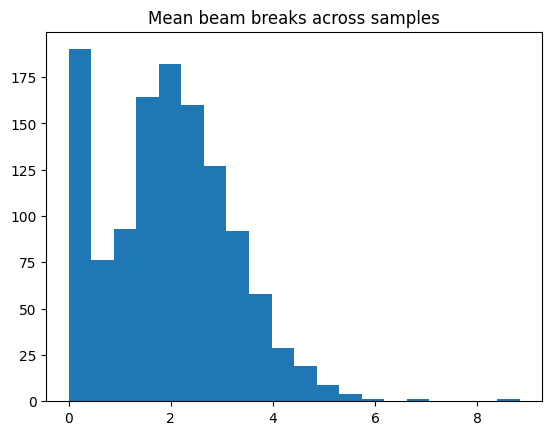

In [27]:
plt.hist(raw_beam_break_binned['mean'], bins=20)
plt.title('Mean beam breaks across samples')

Text(0.5, 1.0, 'Std beam breaks across samples')

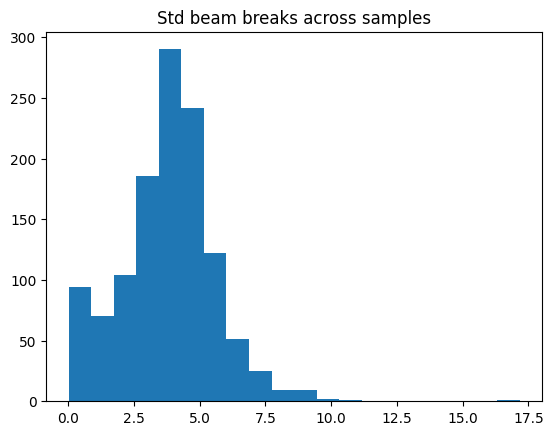

In [28]:
plt.hist(raw_beam_break_binned['std'], bins=20)
plt.title('Std beam breaks across samples')

Text(0.5, 1.0, 'Percent zero across samples')

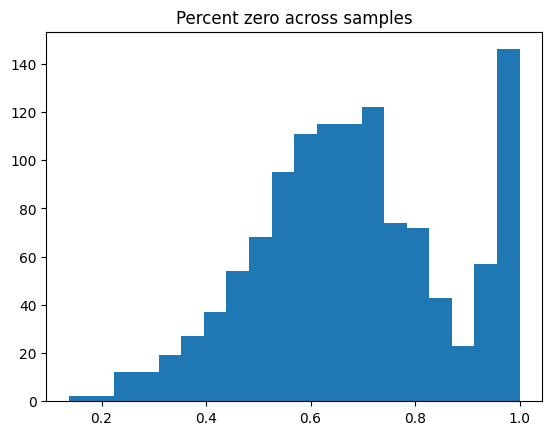

In [29]:
plt.hist(raw_beam_break_binned['Percent_zero'], bins=20)
plt.title('Percent zero across samples')

In [30]:
raw_beam_break_binned.iloc[:, 2:]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std,Percent_zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877,0.755232
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419,0.656767
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999,0.688459
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059,0.586805
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169,0.672115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697,0.494718
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201,0.434722
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046,0.430536
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348,0.495715


In [31]:
beam_binned.shape

(1206, 5017)

In [32]:
np.mean(beam_binned), np.std(beam_binned)

(1.9607247464755817, 4.370635681815)

In [33]:
beam_binned_standardized = standardizer(beam_binned)
beam_binned_standardized

array([[-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       ...,
       [-0.44861317, -0.44861317, -0.44861317, ...,  0.23778583,
         0.23778583,  0.23778583],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.2198135 ,
         0.69538517,  0.23778583],
       [-0.44861317, -0.44861317, -0.44861317, ...,  0.00898617,
        -0.2198135 , -0.44861317]])

In [34]:
new_time_columns = [f't{i}' for i in range(int(beam_break_data_binned_length))]
beam_binned_standardized_df = pd.DataFrame(
    data = beam_binned_standardized, 
    columns=new_time_columns
)
beam_binned_standardized_df

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
1,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
2,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
3,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.695385,3.212182,1.152985,5.957778,-0.219814,0.237786,0.924185,5.728978,0.466586,-0.448613
4,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,0.237786,1.381784,1.152985,0.466586,-0.448613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,1.381784,0.924185,1.610584,1.381784,1.381784,1.152985,0.924185,1.152985,1.152985
1202,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,1.839384,1.610584,1.381784,0.924185,1.381784,1.839384,1.381784,1.839384,1.610584,0.924185
1203,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.466586,0.466586,0.466586,0.008986,-0.448613,-0.448613,-0.448613,0.237786,0.237786,0.237786
1204,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,0.237786,0.237786,1.610584,0.237786,0.466586,1.839384,-0.219814,0.695385,0.237786


In [35]:
final_beam_break_standardized_binned = pd.concat([beam_break_data_binned, beam_binned_standardized_df], axis=1)
final_beam_break_standardized_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
1,M106_M118_Ch26,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
2,M106_M118_Ch27,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
3,M106_M118_Ch28,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.695385,3.212182,1.152985,5.957778,-0.219814,0.237786,0.924185,5.728978,0.466586,-0.448613
4,M106_M118_Ch29,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,0.237786,1.381784,1.152985,0.466586,-0.448613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,1.381784,0.924185,1.610584,1.381784,1.381784,1.152985,0.924185,1.152985,1.152985
1202,M96_M48_Ch29,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,1.839384,1.610584,1.381784,0.924185,1.381784,1.839384,1.381784,1.839384,1.610584,0.924185
1203,M96_M48_Ch30,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.466586,0.466586,0.466586,0.008986,-0.448613,-0.448613,-0.448613,0.237786,0.237786,0.237786
1204,M96_M48_Ch31,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,0.237786,0.237786,1.610584,0.237786,0.466586,1.839384,-0.219814,0.695385,0.237786


In [36]:
final_beam_break_standardized_binned.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_standardized_binned_dropna.csv', index=False)

In [37]:
batch_size = 128
train_set = DataBuilder(raw_beam_break_binned)
test_set = DataBuilder(raw_beam_break_binned)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=len(test_set), shuffle=True)

In [38]:
data, fly_id, genotype = next(iter(train_loader))
print(data.shape)
print(len(fly_id))
print(len(genotype))

ValueError: too many values to unpack (expected 3)

In [42]:
data

NameError: name 'data' is not defined

In [ ]:
fly_id

('M96_M80_Ch9',
 'M106_M7_Ch10',
 'M106_M4_Ch17',
 'M96_M24_Ch24',
 'M106_M14_Ch29',
 'M96_M49_Ch27',
 'M106_M119_Ch5',
 'M106_M29_Ch17',
 'M96_M57_Ch5',
 'M106_M33_Ch1',
 'M106_M116_Ch32',
 'M96_M76_Ch5',
 'M96_M10_Ch29',
 'M106_M111_Ch10',
 'M106_M24_Ch31',
 'M96_M9_Ch13',
 'M106_M15_Ch15',
 'M96_M54_Ch7',
 'M106_M16_Ch25',
 'M119_M50_Ch7',
 'M153_M28_Ch2',
 'M106_M111_Ch31',
 'M96_M56_Ch6',
 'M96_M76_Ch4',
 'M96_M8_Ch26',
 'M106_M4_Ch23',
 'M153_M27_Ch28',
 'M153_M28_Ch1',
 'M106_M30_Ch13',
 'M106_M22_Ch17',
 'M96_M48_Ch6',
 'M96_M76_Ch14',
 'M153_M30_Ch17',
 'M96_M10_Ch2',
 'M96_M55_Ch9',
 'M106_M118_Ch5',
 'M96_M29_Ch1',
 'M106_M117_Ch22',
 'M106_M22_Ch16',
 'M106_M15_Ch29',
 'M96_M10_Ch18',
 'M106_M111_Ch13',
 'M106_M7_Ch13',
 'M106_M116_Ch8',
 'M96_M9_Ch1',
 'M96_M50_Ch15',
 'M96_M24_Ch6',
 'M96_M56_Ch24',
 'M119_M50_Ch21',
 'M106_M30_Ch10',
 'M106_M117_Ch9',
 'M153_M30_Ch22',
 'M96_M25_Ch18',
 'M106_M30_Ch2',
 'M96_M48_Ch18',
 'M96_M55_Ch15',
 'M96_M24_Ch31',
 'M106_M15_Ch10',


In [ ]:
genotype

('SwedArc>attp2M',
 'elavQFxattp40_3_F',
 'elavQFxattp2_1_M',
 'Swed>nsybG4F',
 'Swedishxattp2_1_F',
 'SwedArc>alrmF',
 'attp2xrepo_3_M',
 'attp2xQA40_3_M',
 'London>elavF',
 'attp2xQA42_1_M',
 'Londonxrepo_3_F',
 'London>attp2M',
 'SwedArc>nsybG4F',
 'attp40xQA42_3_F',
 'Swedishxrepo_1_F',
 'London>nsybG4vF',
 'SwedArcxrepo_3_F',
 'London>alrmvF',
 'attp40xalrm_3_F',
 'elavQFxQAb40_F',
 nan,
 'attp40xQA42_1_F',
 'alrm>attp2M',
 'London>attp2M',
 'London>nsybG4F',
 'elavQFxattp2_1_M',
 nan,
 nan,
 'attp2xQA40_1_F',
 'attp40xrepo_3_F',
 'elav>SwedArcM',
 'London>attp2M',
 nan,
 'SwedArc>nsybG4m',
 'elav>attp2M',
 'Londonxalrm_3_F',
 'attp2>nsybG4M',
 'Londonxrepo_1_F',
 'attp40xrepo_3_F',
 'SwedArcxrepo_1_F',
 'SwedArc>nsybG4F',
 'attp40xQA42_3_F',
 'elavQFxattp40_3_F',
 'Londonxattp40_2_M',
 'London>nsybG4vF',
 'London>alrmM',
 'Swed>nsybG4M',
 'alrm>attp2F',
 'attp40xQAb40_F',
 'attp2xQA40_1_F',
 'Londonxrepo_2_F',
 nan,
 'attp2>nsybG4vF',
 'attp2xQA40_1_M',
 'elav>attp2vF',
 'elav>at

In [ ]:
data_test, fly_id_test, genotype_test = next(iter(test_loader))
print(data_test.shape)
print(len(fly_id_test))
print(len(genotype_test))

torch.Size([1363, 5017])
1363
1363


Eigen decomposition of the raw beam break data

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [44]:
beam_binned

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 3., 3., 3.],
       [0., 0., 0., ..., 1., 5., 3.],
       [0., 0., 0., ..., 2., 1., 0.]])

In [45]:
beam_binned.shape

(1206, 5017)

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(beam_binned)

In [48]:
X_scaled

array([[ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       [ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       [ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.53365555,
         0.44327976,  0.44694405],
       [ 0.        ,  0.        ,  0.        , ..., -0.15986664,
         1.03926124,  0.44694405],
       [ 0.        ,  0.        ,  0.        , ...,  0.18689446,
        -0.15270172, -0.45693721]])

In [49]:
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [50]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

In [51]:
cumulative_variance.shape

(1206,)

In [52]:
cumulative_variance

array([0.10019965, 0.12968439, 0.14705978, ..., 1.        , 1.        ,
       1.        ])

In [53]:
index = np.where(cumulative_variance >= 0.90)[0][0]
k = index+1
k

617

Text(0.5, 1.0, 'Cumulative variance across components')

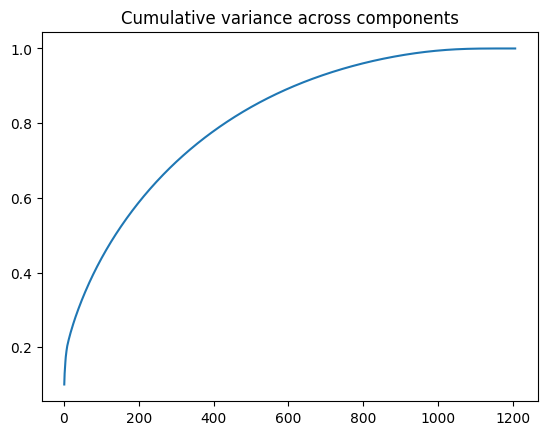

In [54]:
num_components = range(1, 1207)
plt.plot(num_components, cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

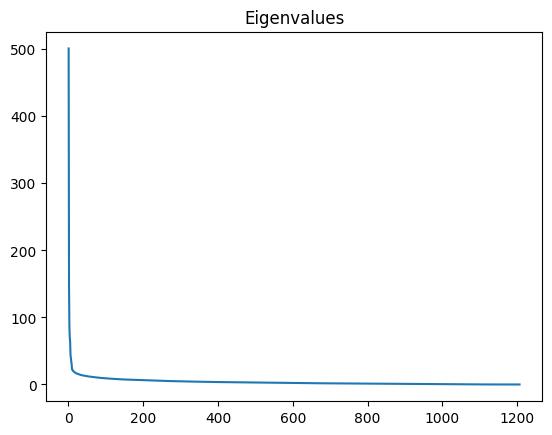

In [55]:
plt.plot(num_components, pca.explained_variance_)
plt.title('Eigenvalues')

In [56]:
from kneed import KneeLocator

In [57]:
elbow = KneeLocator(num_components, pca.explained_variance_, S=1.0, curve='convex', direction='decreasing')

In [59]:
elbow.knee, elbow.knee_y

(19, 17.273357598681205)

Text(0.5, 1.0, 'Eigenvalues')

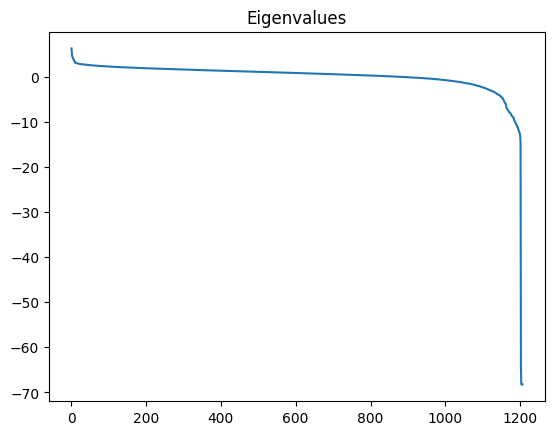

In [ ]:
plt.plot(num_components, np.log(pca.explained_variance_))
plt.title('Eigenvalues')

In [66]:
ind = np.where(pca.explained_variance_ < 10)
ind[0][0]

84

In [ ]:
pca.explained_variance_[20]

16.67549444898621

In [ ]:
np.log(pca.explained_variance_[20])

2.813940243475188

In [65]:
pca.explained_variance_ratio_[19]

0.003392363797651214

Text(0.5, 1.0, 'Explained variance ratio')

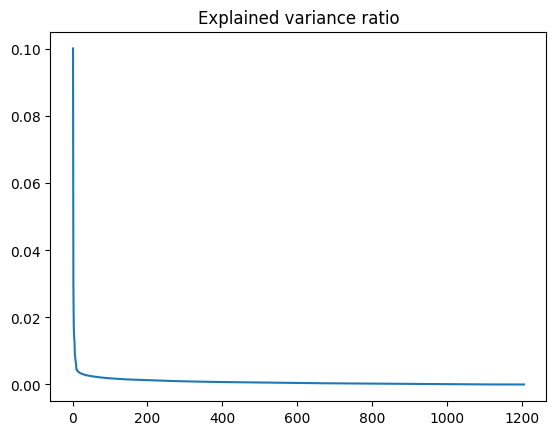

In [ ]:
plt.plot(num_components, pca.explained_variance_ratio_)
plt.title('Explained variance ratio')

In [ ]:
pca.explained_variance_ratio_

array([1.00199651e-01, 2.94847347e-02, 1.73753976e-02, ...,
       4.63251769e-34, 4.63251769e-34, 4.63251769e-34])

Examine aggregated data

In [4]:
agg_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/cleaned_binary_summary_sheet.csv')
agg_data

,Genotype (F>M),Genotype (FxM),Driver,UAS,Sex,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),Sleep/Day (min),...,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,London>alrm,London>alrmF,alrm,London,F,M96,50,17,0,1042.00,...,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,London>alrm,London>alrmF,alrm,London,F,M96,50,18,0,744.25,...,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,London>alrm,London>alrmF,alrm,London,F,M96,50,20,0,957.00,...,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,London>alrm,London>alrmF,alrm,London,F,M96,50,21,0,1030.75,...,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,London>alrm,London>alrmF,alrm,London,F,M96,50,22,0,855.25,...,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,7,0,1083.75,...,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,8,0,1081.75,...,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,9,0,1097.75,...,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,11,0,777.00,...,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [7]:
agg_data['Sex'].value_counts()

Sex
M     639
F     586
vF    115
Name: count, dtype: int64

In [5]:
agg_data.iloc[:, 8:]

,Triage for sleep(Last day of activity < 5),Sleep/Day (min),Bout number/Day,Average bout length/Day,Total activity/Day,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,...,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,0,1042.00,10.75,96.930233,821.25,2.063442,72.00,415.75,626.00,9.50,...,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,0,744.25,32.75,22.725191,1228.25,1.765361,53.75,254.75,488.75,13.25,...,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,0,957.00,14.00,68.357143,895.00,1.853002,85.50,349.00,609.00,10.50,...,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,0,1030.75,17.25,59.753623,630.50,1.540623,71.00,415.00,616.50,14.50,...,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,0,855.25,29.75,28.747899,1079.00,1.845233,32.50,412.25,441.00,20.75,...,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,0,1083.75,41.50,26.114458,404.75,1.136140,6.50,374.75,711.50,40.25,...,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,0,1081.75,53.75,20.125581,782.00,2.182833,12.25,484.50,598.75,30.75,...,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,0,1097.75,40.25,27.273292,737.75,2.155588,8.50,452.75,645.75,29.75,...,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,0,777.00,42.25,18.390533,602.00,0.907994,28.50,239.75,537.25,27.50,...,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [9]:
scaler = StandardScaler()
X_agg_scaled = scaler.fit_transform(agg_data.iloc[:, 8:])
pca = PCA()
pca.fit(X_agg_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Text(0.5, 1.0, 'Cumulative variance across components')

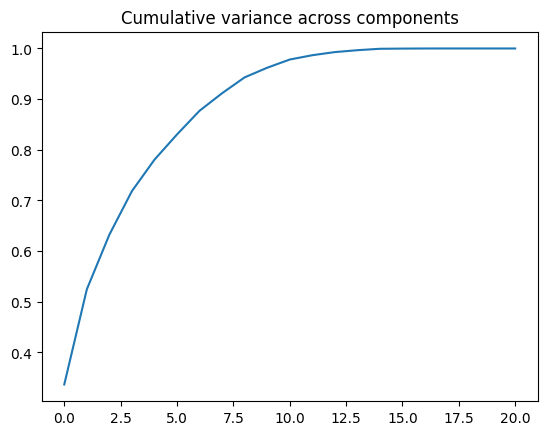

In [12]:
plt.plot(cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

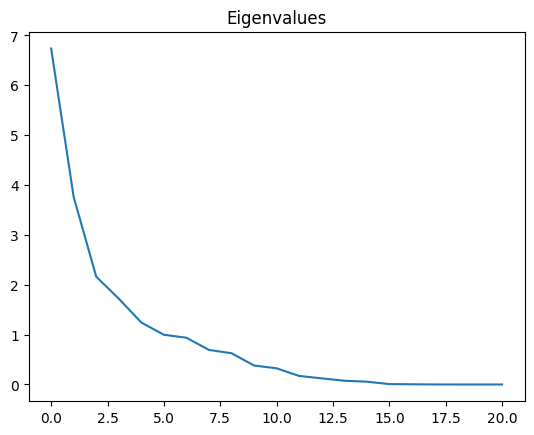

In [14]:
plt.plot(pca.explained_variance_)
plt.title('Eigenvalues')